# Exploration and Exploitation

1. Introduction
2. Multi-Armed Bandits
3. Contextual Bandits
4. MDPs


## Exploration vs. Exploitation Dilemma

- Online decision-making involves a fundamental choice:
    - **Exploitation** Make the best decision given current information
    - **Exploration** Gather more information
- The best long-term strategy may involve short-term sacrifices
- Gather enough information to make the best overall decisions

### Examples:

- Restaurant Selection
    - Exploitation Go to your favourite restaurant
    - Exploration Try a new restaurant
- Online Banner Advertisements
    - Exploitation Show the most successful advert
    - Exploration Show a diﬀerent advert
- Oil Drilling
    - Exploitation Drill at the best known location
    - Exploration Drill at a new location
- Game Playing
    - Exploitation Play the move you believe is best
    - Exploration Play an experimental move


### Principles

#### Naive Exploration
- Add noise to greedy policy (e.g. ε-greedy)
- The simplest approach: occasionally pick a random action instead of the best known one, so the agent stumbles upon unexplored options.

#### Optimistic Initialisation
- Assume the best until proven otherwise
- Start with inflated value estimates for all actions. The agent will naturally try under-explored actions first because they still look promising on paper.

#### Optimism in the Face of Uncertainty
- Prefer actions with uncertain values
- Actively seek out actions where the value estimate has high uncertainty (e.g. UCB). Uncertainty is treated as a bonus — unknown = potentially great.

#### Probability Matching
- Select actions according to the probability they are best
- Sample an action proportional to how likely it is to be optimal (e.g. Thompson Sampling). Balances exploration and exploitation probabilistically.

#### Information State Search
- Lookahead search incorporating value of information
- Plan ahead by treating the *knowledge gained* from an action as part of its reward. Explicitly reasons about which actions are most informative.

## The Multi-Armed Bandit

- A multi-armed bandit is a tuple $\langle \mathcal{A}, \mathcal{R} \rangle$
- $\mathcal{A}$ is a known set of $m$ actions (or "arms")
- $\mathcal{R}^a(r) = \mathbb{P}[r|a]$ is an unknown probability distribution over rewards
- At each step $t$ the agent selects an action $a_t \in \mathcal{A}$
- The environment generates a reward $r_t \sim \mathcal{R}^{a_t}$
- The goal is to maximise cumulative reward $\sum_{\tau=1}^{t} r_\tau$

<img src="imgs/image-124.png" width=200px>

### Simple Explanation

Think of a row of slot machines ("one-armed bandits"), each with a different — and unknown — payout rate.

- **Arms**: the $m$ machines you can pull.
- **$\mathcal{R}^a$**: each machine has its own hidden reward distribution; you don't know which is best.
- **At each step**: you pick one machine to pull.
- **Reward**: you observe a random payout sampled from that machine's distribution.
- **Goal**: maximise total winnings over time.

The core challenge is the **explore/exploit trade-off** — do you keep pulling the machine that has paid out best so far, or try others that might be even better?

### Regret

- The **action-value** is the mean reward for action $a$:
$$Q(a) = \mathbb{E}[r|a]$$

- The **optimal value** $V^*$ is:
$$V^* = Q(a^*) = \max_{a \in \mathcal{A}} Q(a)$$

- The **regret** is the opportunity loss for **one step**:
$$l_t = \mathbb{E}[V^* - Q(a_t)]$$

- The **total regret** is the total opportunity loss:
$$L_t = \mathbb{E}\left[\sum_{\tau=1}^{t} V^* - Q(a_\tau)\right]$$

- Maximise cumulative reward $\equiv$ minimise total regret

#### Simple Explanation

- **$Q(a)$**: the average reward you expect from pulling arm $a$.
- **$V^*$**: the average reward of the *best possible* arm — the ceiling you're aiming for.
- **Regret at step $t$**: how much worse your chosen action $a_t$ is compared to always picking the best arm. Zero regret means you picked optimally.
- **Total regret $L_t$**: the accumulated gap over all steps — how much reward you *missed out on* by not always picking the best arm.

Minimising total regret and maximising total reward are exactly the same objective — you want your choices to be as close to the optimal arm as possible, as often as possible.

### Counting Regret

- The **count** $N_t(a)$ is the expected number of selections for action $a$
- The **gap** $\Delta_a$ is the difference in value between action $a$ and optimal action $a^*$:
$$\Delta_a = V^* - Q(a)$$
- Regret is a function of gaps and counts:

$$L_t = \mathbb{E}\left[\sum_{\tau=1}^{t} V^* - Q(a_\tau)\right]$$
$$= \sum_{a \in \mathcal{A}} \mathbb{E}[N_t(a)](V^* - Q(a))$$
$$= \sum_{a \in \mathcal{A}} \mathbb{E}[N_t(a)]\, \Delta_a$$

- A good algorithm ensures small counts for large gaps
- **Problem: gaps are not known!**

#### Simple Explanation

Total regret decomposes neatly: for each arm $a$, multiply **how often you pulled it** by **how suboptimal it was**, then sum across all arms.

$$L_t = \sum_{a} \underbrace{\mathbb{E}[N_t(a)]}_{\text{how often}} \times \underbrace{\Delta_a}_{\text{how bad}}$$

- A large gap $\Delta_a$ means arm $a$ is much worse than optimal — you want to pull it rarely.
- A small gap means the arm is nearly as good as optimal — pulling it occasionally is not costly.

The ideal algorithm quickly identifies bad arms and stops pulling them. The catch: you never directly observe $\Delta_a$, so you have to *infer* which arms are bad from noisy reward samples.

### Linear or Sublinear Regret

<img src=imgs/image-125.png width=500px />

- If an algorithm **forever** explores it will have linear total regret
- If an algorithm **never** explores it will have linear total regret
- Is it possible to achieve sublinear total regret?

#### Simple Explanation

The graph shows total regret over time for three strategies:

- **Greedy** (blue): never explores — locks in on whatever looked best early on, which may be suboptimal. Regret grows linearly because it keeps making the same mistake forever.
- **ε-greedy** (red): always explores at fixed rate — better than pure greedy, but still linear because it keeps wasting a fixed fraction of steps on random actions even after learning enough.
- **Decaying ε-greedy** (black): explores a lot early, then less and less over time — regret curve bends and flattens, achieving **sublinear** growth.

**Key insight**: both extremes (always explore, never explore) are equally bad in the long run — linear regret. The goal is an algorithm that explores *just enough* early on and gradually commits to the best arm, so that total regret grows sublinearly (e.g. $O(\log t)$).

### Greedy Algorithm

- We consider algorithms that estimate $\hat{Q}_t(a) \approx Q(a)$
- Estimate the value of each action by Monte-Carlo evaluation:

$$\hat{Q}_t(a) = \frac{1}{N_t(a)} \sum_{t=1}^{T} r_t \mathbf{1}(a_t = a)$$

- The **greedy** algorithm selects the action with highest estimated value:

$$a_t^* = \underset{a \in \mathcal{A}}{\operatorname{argmax}}\, \hat{Q}_t(a)$$

- Greedy can lock onto a suboptimal action forever
- $\Rightarrow$ Greedy has linear total regret

#### Simple Explanation

- **$\hat{Q}_t(a)$**: running average of all rewards received when arm $a$ was pulled. The indicator $\mathbf{1}(a_t = a)$ just means "only count timesteps where we actually chose $a$".
- **Greedy selection**: always pull the arm with the highest average reward so far — pure exploitation, zero exploration.

**Why it fails**: if by chance a suboptimal arm looks good early on (lucky initial pulls), greedy commits to it and never tries the others enough to discover the true best arm. That early mistake compounds forever → linear regret.

### ε-Greedy Algorithm

The **ε-greedy** algorithm always keeps exploring — it never fully stops trying random actions.

**Action selection rule:**

- With probability **1 − ε**: exploit — pick the action with the highest estimated value:
  `a = argmax Q̂(a)` over all `a ∈ A`
- With probability **ε**: explore — pick a **random action**

**Regret bound:**

Because ε is constant, at every step there is always a fixed chance of picking a suboptimal action.
This means the per-step regret never goes to zero, giving a **lower bound on cumulative regret**:

$$
l_t \geq \frac{\varepsilon}{\mathcal{A}} \sum_{a \in \mathcal{A}} \Delta_a
$$

where Δ_a is the **gap** between the optimal action's value and action `a`'s value.

**Consequence:** constant ε → **linear total regret** — regret grows proportionally with time, which is suboptimal compared to algorithms that decay exploration over time.

### Optimistic Initialisation

**Core idea:** initialise Q(a) to an artificially high value for all actions, then update using incremental Monte-Carlo.

**Requirement:** N(a) > 0 for all actions (each action must be "seen" at least once at the start).

**Update rule:**

$$
\hat{Q}_t(a_t) = \hat{Q}_{t-1} + \frac{1}{N_t(a_t)}(r_t - \hat{Q}_{t-1})
$$

This is a running average: the new estimate moves toward the observed reward $r_t$ by a step size of $1/N(a_t)$.

**Why it encourages exploration:**

By initialising Q(a) high, every action looks promising at the start.
Actions that get selected quickly disappoint (real rewards are lower), so the agent naturally tries other actions — systematic early exploration without an explicit ε.

**Limitation:**

The agent can still **lock onto a suboptimal action** once estimates converge, because there is no forced exploration mechanism after the initial phase.

**Regret:**

- Greedy + optimistic initialisation → **linear total regret**
- ε-greedy + optimistic initialisation → **linear total regret**

Optimistic initialisation improves early exploration but does **not** fix the fundamental regret scaling — both combinations still grow linearly over time.

## Decaying εt-Greedy Algorithm

Instead of a fixed ε, use a **schedule** ε₁, ε₂, ... that decreases over time.

**A concrete schedule:**

- c > 0 — a tunable constant
- $d = \underset{a | Δ_a > 0}{min} Δ_i$ — the **smallest gap** among suboptimal actions (how close the best suboptimal action is to the optimal)
- The decay schedule:

$$
\varepsilon_t = \min\left\{1,\ \frac{c|\mathcal{A}|}{d^2 t}\right\}
$$

Exploration probability shrinks as `1/t` — early on ε ≈ 1 (explore a lot), later ε → 0 (exploit more and more).

**Result:** decaying εt-greedy achieves **logarithmic asymptotic total regret** — a major improvement over linear regret.

**The catch:**

The schedule depends on `d`, the minimum gap between actions.
This requires **advance knowledge of the reward gaps** Δ_a, which is typically unknown in practice.

**Motivation for what comes next:**

Goal: find an algorithm that achieves **sublinear regret** for any multi-armed bandit problem, **without** knowing the reward distribution R or the gaps.


### UCB (Upper Confidence Bound)

UCB  is the standard answer to that goal.

Instead of using gaps explicitly, UCB estimates **uncertainty** for each action and adds an exploration bonus:


#### Lower Bound

**Key insight:** how hard a bandit problem is depends on how similar the suboptimal arms look to the optimal arm.

- If a suboptimal arm has a reward distribution very close to the optimal, it is hard to distinguish them → more exploration needed → more regret
- This similarity is measured by the **KL divergence** $KL(R^a || R^{a*})$: how different arm `a`'s distribution is from the optimal arm `a*`

**Theorem (Lai and Robbins):**

Asymptotic total regret is **at least** logarithmic in the number of steps:

$$
\lim_{t \to \infty} L_t \geq \log t \sum_{a | \Delta_a > 0} \frac{\Delta_a}{KL(\mathcal{R}^a || \mathcal{R}^{a^*})}
$$

**Reading the bound:**

- Large Δ_a (suboptimal arm is clearly bad) but also large KL (easy to distinguish) → small contribution to regret
- Small Δ_a and small KL (arm looks almost like the optimal) → large contribution → hard problem

**Implication:**

No algorithm can do better than logarithmic regret in general. Logarithmic growth is therefore the **gold standard** — an algorithm that achieves it (like UCB) is asymptotically optimal.

#### Uncertainty and Exploration

<img src=imgs/image-126.png width=600px>

The plot shows posterior distributions p(Q) over the value of three actions a₁, a₂, a₃.

- **Q(a₁)** (blue): wide, flat distribution — very uncertain, mean looks low
- **Q(a₂)** (red): moderate uncertainty, medium mean
- **Q(a₃)** (green): narrow, peaked distribution — high confidence, highest mean

**Which action should we pick?**

The greedy choice is a₃ (highest estimated value). But a₁ has enormous uncertainty — its true value **could** be much higher than it currently appears.

**The principle:**

> The more uncertain we are about an action's value, the more important it is to explore it — it could turn out to be the best action.

This is the intuition behind UCB: don't just pick the action with the highest estimated value, pick the one with the highest **upper confidence bound**, rewarding uncertainty as a reason to explore.

<img src=imgs/image-127.png width=600px>

- After picking the **blue** action, we are less uncertain about its value
- This makes us more likely to pick another action next
- The process repeats until we home in on the best action

#### Upper Confidence Bounds

**Core idea:** for each action, maintain an upper confidence bound $Û_t(a)$ such that the true value Q(a) lies below the estimated value plus the bound with high probability:

$$
Q(a) \leq \hat{Q}_t(a) + \hat{U}_t(a)
$$

**The bound depends on how many times action `a` has been selected, N_t(a):**

- Small $N_t(a)$ → large $ Û_t(a)$: the estimate is uncertain, so the upper bound is wide
- Large $N_t(a)$ → small $Û_t(a)$: the estimate is accurate, so the upper bound is tight

**Action selection — pick the action with the highest UCB:**

$$
a_t = \underset{a \in \mathcal{A}}{\argmax}\ \hat{Q}_t(a) + \hat{U}_t(a)
$$

**Intuition:** this automatically balances exploration and exploitation:
- A well-explored action wins if its **estimated value** is high
- An under-explored action wins if its **uncertainty bonus** is high
- Once an action is pulled more, its bonus shrinks and it must compete on value alone

#### Hoeffding's Inequality

**Theorem (Hoeffding's Inequality):**

Let $X₁, ..., X_t$ be i.i.d. random variables in [0,1], and let $\bar{X}_t = \frac{1}{t} \sum_{\tau=1}^{t} X_\tau$ be the sample mean. Then:

$$
\mathbb{P}\left[\mathbb{E}[X] > \bar{X}_t + u\right] \leq e^{-2tu^2}
$$

**Plain English:** the probability that the true mean exceeds the sample mean by more than `u` drops exponentially as you collect more samples `t` or increase the margin `u`. This is valid for any distribution.

**Applying this to the bandit:**

Conditioned on selecting action `a`, treat rewards as i.i.d. samples. Then:

$$
\mathbb{P}\left[Q(a) > \hat{Q}_t(a) + U_t(a)\right] \leq e^{-2N_t(a)U_t(a)^2}
$$

- Q(a) is the true value (the true mean)
- Q̂_t(a) is the sample mean after N_t(a) pulls
- U_t(a) is the confidence width we want to set

**Key use:** we can choose U_t(a) to make this probability as small as we like — this tells us **how wide the confidence bound needs to be** to guarantee Q(a) ≤ Q̂_t(a) + U_t(a) with high probability.

#### Calculating Upper Confidence Bounds

**Step 1:** pick a probability `p` that the true value exceeds the UCB, then solve for $U_t(a)$.

From Hoeffding's inequality, set the bound equal to `p`:

$$
e^{-2N_t(a)U_t(a)^2} = p
$$

Solving for $U_t(a)$:

$$
U_t(a) = \sqrt{\frac{-\log p}{2N_t(a)}}
$$

The bound shrinks as $N_t(a)$ grows — the more we pull action `a`, the tighter the confidence interval.

**Step 2:** reduce `p` over time so we keep selecting the optimal action as t → ∞.

A natural choice: `p = t⁻⁴`, which shrinks fast enough to ensure convergence. Substituting:

$$
U_t(a) = \sqrt{\frac{2 \log t}{N_t(a)}}
$$

**Intuition:**
- $\log t$ grows slowly → the bound keeps widening slightly over time, ensuring under-explored actions stay attractive
- $N_t(a)$ in the denominator → the more an action is pulled, the tighter its bound becomes

This gives the **UCB1** confidence bound, which achieves logarithmic total regret.


##### UCB1

**Action selection rule:**

$$
a_t = \underset{a \in \mathcal{A}}{\argmax}\ Q(a) + \sqrt{\frac{2 \log t}{N_t(a)}}
$$

At each step, pick the action with the highest estimated value plus an exploration bonus that grows with total time `t` and shrinks with how often action `a` has been pulled.

**Theorem:**

The UCB1 algorithm achieves **logarithmic asymptotic total regret**:

$$
\lim_{t \to \infty} L_t \leq 8 \log t \sum_{a | \Delta_a > 0} \Delta_a
$$

**What this means:**

- Regret is bounded by $\log t$ times the sum of gaps Δ_a over all suboptimal actions
- This matches the **Lai-Robbins lower bound** up to a constant factor — UCB1 is asymptotically optimal
- Crucially, this is achieved **without any knowledge of the reward distributions** R or the gaps $Δ_a$

## Bayesian Bandits

So far, standard bandit algorithms make no assumptions about the reward distribution $\mathcal{R}$ — except that rewards are bounded.

**Bayesian bandits** take a different approach: they exploit **prior knowledge** about the reward distribution by maintaining a prior $p[\mathcal{R}]$ and updating it as data arrives.

### Posterior over Rewards

At each step, the agent maintains a **posterior distribution** over rewards:

$$p[\mathcal{R} \mid h_t]$$

where the history $h_t$ captures everything observed so far:

$$h_t = a_1, r_1, \ldots, a_{t-1}, r_{t-1}$$

This posterior is updated via Bayes' rule after each (action, reward) pair is observed.

### Using the Posterior for Exploration

The posterior is not just tracked — it actively **guides exploration**. Two main strategies:

- **Bayesian UCB** — construct upper confidence bounds using posterior uncertainty (e.g., mean + $k$ × posterior std). Arms with high uncertainty or high expected reward are preferred.
- **Thompson Sampling** (probability matching) — sample a reward parameter $\theta$ from the posterior for each arm, then act greedily on the sample. Exploration emerges naturally from posterior uncertainty.

### Key Tradeoff

Bayesian bandits achieve **better performance** than frequentist methods **when the prior is accurate**. If the prior is misspecified, performance can degrade. The benefit is essentially free exploration guidance from prior knowledge, at the cost of needing that knowledge upfront.

### Bayesian UCB Example: Independent Gaussians

#### Model Assumption

Each arm $a$ has a Gaussian reward distribution:

$$\mathcal{R}_a(r) = \mathcal{N}(r;\, \mu_a, \sigma_a^2)$$

The parameters $\mu_a$ (mean) and $\sigma_a^2$ (variance) are **unknown** and must be inferred from observed rewards.

<img src=imgs/image-128.png />

#### Gaussian Posterior

By Bayes' law, the posterior over $(\mu_a, \sigma_a^2)$ after history $h_t$ is:

$$p\left[\mu_a, \sigma_a^2 \mid h_t\right] \propto p\left[\mu_a, \sigma_a^2\right] \prod_{t \;\mid\; a_t = a} \mathcal{N}(r_t;\, \mu_a, \sigma_a^2)$$

- The prior $p[\mu_a, \sigma_a^2]$ encodes initial beliefs about the arm.
- The likelihood product runs only over timesteps where arm $a$ was actually selected.
- The result is a posterior that **sharpens** (lower variance) as more pulls of arm $a$ are observed.

### Action Selection — Bayesian UCB

Pick the arm that maximises the **upper confidence bound** derived from the posterior:

$$a_t = \underset{a}{\operatorname{argmax}}\; \mu_a + c\,\sigma_a \big/ \sqrt{N(a)}$$

where:
- $\mu_a$ — posterior mean of arm $a$ (exploitation term)
- $\sigma_a / \sqrt{N(a)}$ — posterior standard deviation of the sample mean; shrinks as $N(a)$ (pull count) grows
- $c$ — exploration coefficient controlling the confidence level

#### Intuition

The diagram shows three arms with overlapping posterior distributions $Q(a_i)$. Arms with fewer pulls have **wider** posteriors (higher uncertainty), so their UCB extends further right — making them attractive to explore. As an arm is pulled more, $N(a)$ grows, its posterior narrows, and the UCB tightens around the true mean. This naturally balances **exploitation** (high $\mu_a$) with **exploration** (high uncertainty).

#### Probability Matching

##### Core Idea

**Probability matching** selects each action $a$ with probability equal to the probability that $a$ is the **optimal action** given the current history:

$$\pi(a \mid h_t) = \mathbb{P}\left[Q(a) > Q(a'),\, \forall a' \neq a \mid h_t\right]$$

Rather than always picking the highest UCB, the agent **samples actions proportionally to how likely they are to be best**. This is also known as **Thompson Sampling** when implemented by sampling from the posterior.

#### Why It Works: Optimism Under Uncertainty

Probability matching is **optimistic in the face of uncertainty**:

- An arm with **high uncertainty** (wide posterior) has a larger chance of being the maximum — even if its posterior mean is not the highest.
- An arm with **low uncertainty** (many pulls, narrow posterior) contributes a probability close to 0 or 1 depending on its mean.

This means uncertain arms are naturally explored more often, without needing an explicit exploration bonus like UCB.

#### Practical Implementation

Computing $\pi(a \mid h_t)$ analytically from the posterior is generally **intractable** for most distributions. In practice it is approximated by **Thompson Sampling**:

1. For each arm $a$, sample $\tilde{Q}(a) \sim p[Q(a) \mid h_t]$
2. Select $a_t = \operatorname{argmax}_a \tilde{Q}(a)$

Over many steps, the frequency with which arm $a$ is selected converges to $\pi(a \mid h_t)$, making Thompson Sampling an efficient Monte Carlo implementation of probability matching.

##### Thompson Sampling

###### Connection to Probability Matching

Thompson sampling is a practical algorithm that **implements probability matching exactly**. The policy is:

$$\pi(a \mid h_t) = \mathbb{P}\left[Q(a) > Q(a'),\, \forall a' \neq a \mid h_t\right]$$

This can be rewritten as an expectation over the posterior:

$$= \mathbb{E}_{\mathcal{R} \mid h_t}\left[\mathbf{1}\!\left(a = \underset{a \in \mathcal{A}}{\operatorname{argmax}}\; Q(a)\right)\right]$$

The indicator $\mathbf{1}(\cdot)$ is 1 when $a$ is the greedy action under a sampled $\mathcal{R}$. Averaging over the posterior recovers the exact probability matching policy — no approximation needed.

###### Algorithm

Each timestep proceeds in four steps:

1. **Compute posterior** — use Bayes' law to update $p[\mathcal{R} \mid h_t]$ from the history of (action, reward) pairs.
2. **Sample** — draw a reward distribution $\mathcal{R} \sim p[\mathcal{R} \mid h_t]$.
3. **Evaluate** — compute action values from the sample: $Q(a) = \mathbb{E}[\mathcal{R}_a]$.
4. **Act greedily** — select $a_t = \operatorname{argmax}_{a \in \mathcal{A}}\; Q(a)$.

Because the sample in step 2 varies randomly, uncertain arms (wide posteriors) frequently produce high sampled values and get selected — exploration emerges automatically.

###### Optimality

Thompson sampling achieves the **Lai and Robbins lower bound** — the information-theoretic minimum regret for any consistent bandit algorithm. This makes it not just practical but asymptotically optimal, which is a remarkably strong guarantee for such a simple procedure.

## Implementation: Thompson Sampling on Multi-Armed Bandits

Using `gym-bandits` (`MultiarmedBandits-v0`): 10-armed Gaussian bandit where each arm $a$ has true mean $q_*(a) \sim \mathcal{N}(0,1)$ and rewards $R \sim \mathcal{N}(q_*(a), 1)$.

**Thompson Sampling** (Gaussian case):
1. Maintain posterior $\mathcal{N}(\hat{\mu}_a, \hat{\sigma}^2_a)$ for each arm
2. Sample $\theta_a \sim \mathcal{N}(\hat{\mu}_a, \hat{\sigma}_a)$ for all arms
3. Select $a_t = \arg\max_a \theta_a$
4. Observe reward $r_t$, update posterior via Bayes' rule

We compare against $\varepsilon$-greedy and UCB1.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gym
import gym_bandits

%matplotlib inline

In [4]:
env = gym.make("MultiarmedBandits-v0")
env.reset()

n_arms = env.action_space.n
print(f"Number of arms: {n_arms}")
print(f"True values q*(a): {np.round(env.values, 3)}")
print(f"Optimal arm: {env.optimal} with value {env.values[env.optimal]:.3f}")

Number of arms: 10
True values q*(a): [ 1.081  0.891 -0.785 -0.864 -0.127 -1.674  0.083 -0.363  1.014 -0.378]
Optimal arm: 0 with value 1.081


In [6]:
class ThompsonSampling:
    """Thompson Sampling for Gaussian bandits with known variance (σ²=1).

    Posterior for each arm: N(mu_a, sigma²_a)
    Prior: N(0, 1) for each arm.
    Update rule (conjugate Gaussian):
        sigma²_post = 1 / (1/sigma²_prior + n / sigma²_likelihood)
        mu_post = sigma²_post * (mu_prior/sigma²_prior + sum(rewards) / sigma²_likelihood)
    """

    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.mu = np.zeros(n_arms)  # posterior means
        self.sigma2 = np.ones(n_arms)  # posterior variances
        self.counts = np.zeros(n_arms)
        self.sum_rewards = np.zeros(n_arms)

    def select_arm(self):
        samples = np.random.normal(self.mu, np.sqrt(self.sigma2))
        return np.argmax(samples)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.sum_rewards[arm] += reward
        # Bayesian update: prior N(0,1), likelihood variance = 1
        self.sigma2[arm] = 1.0 / (1.0 + self.counts[arm])
        self.mu[arm] = self.sigma2[arm] * self.sum_rewards[arm]


class EpsilonGreedy:
    """ε-greedy strategy."""

    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.counts = np.zeros(n_arms)
        self.Q = np.zeros(n_arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)
        return np.argmax(self.Q)

    def update(self, arm, reward):
        self.counts[arm] += 1
        # incremental mean update
        self.Q[arm] += (reward - self.Q[arm]) / self.counts[arm]


class UCB1:
    """Upper Confidence Bound (UCB1)."""

    def __init__(self, n_arms, c=2.0):
        self.n_arms = n_arms
        self.c = c
        self.counts = np.zeros(n_arms)
        self.Q = np.zeros(n_arms)
        self.t = 0

    def select_arm(self):
        self.t += 1
        # play each arm once first
        for a in range(self.n_arms):
            if self.counts[a] == 0:
                return a
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.counts)
        return np.argmax(ucb)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.counts[arm]

In [16]:
def run_experiment(env, agent, n_steps=1000):
    """Run a bandit experiment, return per-step regret and selected arms."""
    optimal_value = env.values[env.optimal]
    regrets = np.zeros(n_steps)
    actions = np.zeros(n_steps, dtype=int)

    for t in range(n_steps):
        arm = agent.select_arm()
        _, reward, _, _ = env.step(arm)
        reward = float(np.squeeze(reward))
        agent.update(arm, reward)

        actions[t] = arm
        regrets[t] = optimal_value - env.values[arm]  # expected regret

    return regrets, actions


def run_multiple(env, agent_cls, agent_kwargs, n_steps=1000, n_runs=200):
    """Average over multiple runs (same bandit instance, different randomness)."""
    cum_regrets = np.zeros((n_runs, n_steps))

    for run in range(n_runs):
        agent = agent_cls(**agent_kwargs)
        regrets, _ = run_experiment(env, agent, n_steps)
        cum_regrets[run] = np.cumsum(regrets)

    return cum_regrets

In [17]:
n_steps = 1000
n_runs = 200

agents = {
    "Thompson Sampling": (ThompsonSampling, {"n_arms": n_arms}),
    "ε-greedy (ε=0.1)": (EpsilonGreedy, {"n_arms": n_arms, "epsilon": 0.1}),
    "UCB1 (c=2)": (UCB1, {"n_arms": n_arms, "c": 2.0}),
}

results = {}
for name, (cls, kwargs) in agents.items():
    print(f"Running {name}...")
    results[name] = run_multiple(env, cls, kwargs, n_steps=n_steps, n_runs=n_runs)

print("Done.")

Running Thompson Sampling...
Running ε-greedy (ε=0.1)...
Running UCB1 (c=2)...
Done.


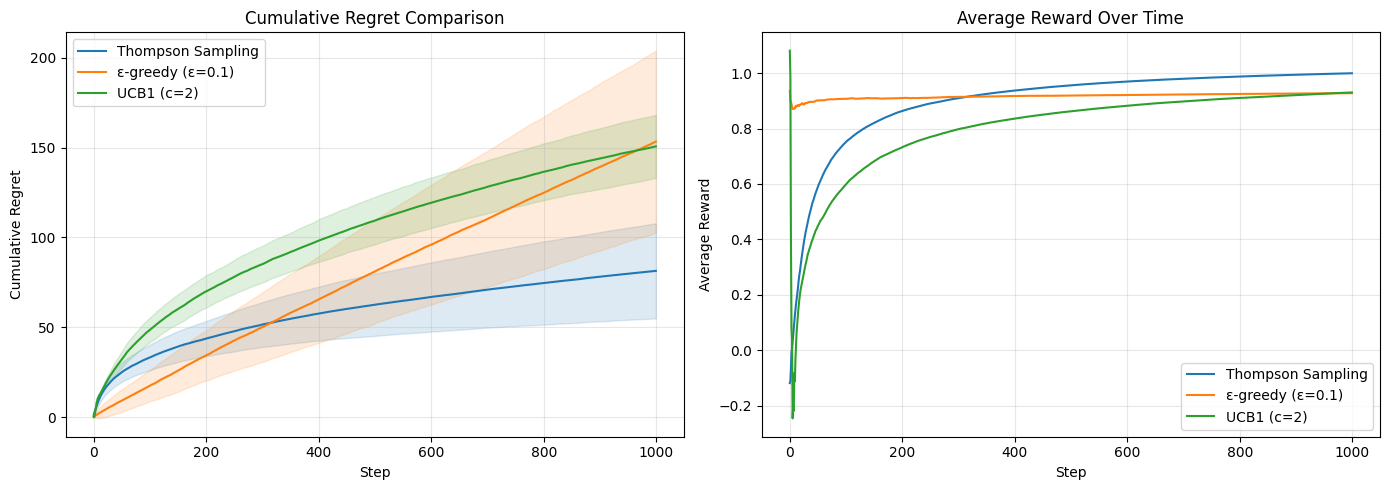

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"Thompson Sampling": "C0", "ε-greedy (ε=0.1)": "C1", "UCB1 (c=2)": "C2"}

# --- Cumulative Regret ---
ax = axes[0]
for name, cum_regret in results.items():
    mean = cum_regret.mean(axis=0)
    std = cum_regret.std(axis=0)
    ax.plot(mean, label=name, color=colors[name])
    ax.fill_between(
        range(n_steps), mean - std, mean + std, alpha=0.15, color=colors[name]
    )

ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Regret")
ax.set_title("Cumulative Regret Comparison")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Average Reward ---
ax = axes[1]
for name, cum_regret in results.items():
    # average reward = optimal_value - regret/t
    optimal_value = env.values[env.optimal]
    avg_reward = optimal_value - cum_regret.mean(axis=0) / np.arange(1, n_steps + 1)
    ax.plot(avg_reward, label=name, color=colors[name])

ax.set_xlabel("Step")
ax.set_ylabel("Average Reward")
ax.set_title("Average Reward Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

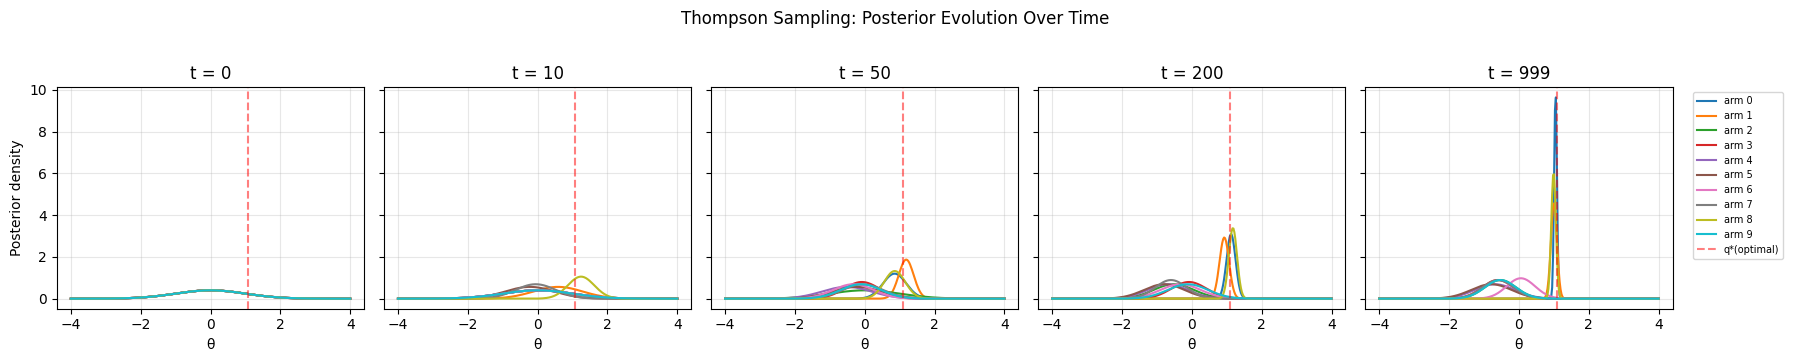

In [21]:
from scipy.stats import norm

# Run one episode and track posteriors at snapshots
snapshots = [0, 10, 50, 200, 999]
ts = ThompsonSampling(n_arms)
posterior_history = {t: None for t in snapshots}

for t in range(n_steps):
    if t in snapshots:
        posterior_history[t] = (ts.mu.copy(), ts.sigma2.copy())
    arm = ts.select_arm()
    _, reward, _, _ = env.step(arm)
    ts.update(arm, float(np.squeeze(reward)))

# Final state
posterior_history[999] = (ts.mu.copy(), ts.sigma2.copy())

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 3.5), sharey=True)
x = np.linspace(-4, 4, 300)

for i, t in enumerate(snapshots):
    ax = axes[i]
    mu, sigma2 = posterior_history[t]
    for a in range(n_arms):
        pdf = norm.pdf(x, mu[a], np.sqrt(sigma2[a]))
        ax.plot(x, pdf, label=f"arm {a}")
    # mark true optimal
    ax.axvline(
        env.values[env.optimal], color="red", ls="--", alpha=0.5, label="q*(optimal)"
    )
    ax.set_title(f"t = {t}")
    ax.set_xlabel("θ")
    if i == 0:
        ax.set_ylabel("Posterior density")
    ax.grid(True, alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
fig.suptitle("Thompson Sampling: Posterior Evolution Over Time", y=1.02)
plt.tight_layout()
plt.show()

## information state search

### Value of Information

Exploration is useful because it **gains information**. But can we *quantify* how valuable that information actually is?

**Definition of value of information:**
- How much reward a decision-maker would be willing to pay to obtain the information *before* making a decision
- Formally: long-term reward *after* receiving information minus the immediate reward (opportunity cost of not acting greedily now)

**Key insight:** Information gain is higher in **uncertain situations** — if you already know the best action, new information adds little. If you're unsure, it can be decisive.

> **Plain English:** Exploring a slot machine you know nothing about is worth more than exploring one you've already pulled 1000 times.

**Consequence:** It makes sense to **explore uncertain situations more** — uncertainty signals high potential information gain.

**Payoff:** If we can compute the value of information exactly, we can trade off exploration and exploitation *optimally* — no heuristics needed, just pure expected-value reasoning.

> This is the theoretical foundation behind algorithms like **UCB** (Upper Confidence Bound) and **Bayesian RL**, which make exploration decisions based on uncertainty estimates rather than arbitrary ε schedules.

### Information State Space

Bandits are usually framed as *one-step* problems (pick an arm, get reward, repeat independently). But we can reframe them as a **sequential decision-making problem** — i.e., a full MDP — by tracking what the agent has learned over time.

**Information state $\tilde{s}$:**
- A *sufficient statistic* of the history: $\tilde{s}_t = f(h_t)$
- It compresses everything the agent has observed so far (actions taken, rewards received) into a single state representation
- No need to store the full history — $\tilde{s}$ captures all that matters for future decisions

> **Example:** In a Bernoulli bandit, the information state for each arm could be $(\alpha, \beta)$ — the counts of successes and failures — which fully summarizes the posterior belief.

**Transitions:**
- Taking action $a$ yields a new observation (reward), which updates the information state
- This transition $\tilde{s} \to \tilde{s}'$ happens with probability $\tilde{\mathcal{P}}^a_{\tilde{s},\tilde{s}'}$
- The transition is *stochastic* because the reward/observation is random

**Result — the augmented MDP $\tilde{\mathcal{M}}$:**

$$\tilde{\mathcal{M}} = \langle \tilde{\mathcal{S}}, \mathcal{A}, \tilde{\mathcal{P}}, \mathcal{R}, \gamma \rangle$$

| Component | Meaning |
|---|---|
| $\tilde{\mathcal{S}}$ | Space of all possible information states (belief states) |
| $\mathcal{A}$ | Action set (same as original bandit) |
| $\tilde{\mathcal{P}}$ | Transition dynamics over information states |
| $\mathcal{R}$ | Reward function |
| $\gamma$ | Discount factor |

> **Key insight:** Solving this MDP *optimally* automatically balances exploration and exploitation — exploration is just the natural consequence of acting to maximize long-term reward in a state space where uncertainty is part of the state.

## Contextual bandits


A **contextual bandit** extends the standard bandit by adding a *state* (context) observed before each action. It is a tuple $\langle \mathcal{A}, \mathcal{S}, \mathcal{R} \rangle$:

| Component | Definition | Meaning |
|---|---|---|
| $\mathcal{A}$ | Known set of actions | The "arms" available |
| $\mathcal{S} = \mathbb{P}[s]$ | Unknown distribution over states | The context space |
| $\mathcal{R}^a_s(r) = \mathbb{P}[r \mid s, a]$ | Unknown reward distribution | Reward depends on both context and action |

**At each step $t$:**
1. Environment samples context $s_t \sim \mathcal{S}$
2. Agent observes $s_t$ and selects action $a_t \in \mathcal{A}$
3. Environment samples reward $r_t \sim \mathcal{R}^{a_t}_{s_t}$

**Goal:** Maximise cumulative reward $\sum_{\tau=1}^{t} r_\tau$

> **vs. plain bandit:** In a standard bandit, the best action is fixed — you just need to find it. In a contextual bandit, the best action *depends on the context*, so the agent must learn a **policy** $\pi: \mathcal{S} \to \mathcal{A}$ rather than a single best arm.

> **vs. full MDP:** There is still **no state transition** — the next context $s_{t+1}$ is drawn fresh from $\mathcal{S}$ independently of $s_t$ and $a_t$. Actions influence rewards but not future states. This makes it strictly between a bandit and an MDP.

> **Example:** Online ad placement — the context is the user's profile, the actions are ads to show, and the reward is whether the user clicks. The best ad varies by user.

### Linear Regression for Contextual Bandits

**Action-value function** — the expected reward for taking action $a$ in context $s$:

$$Q(s, a) = \mathbb{E}[r \mid s, a]$$

**Linear approximation** — instead of a table, approximate $Q$ with a linear model:

$$Q_\theta(s, a) = \phi(s, a)^\top \theta \approx Q(s, a)$$

- $\phi(s, a) \in \mathbb{R}^n$ is a **feature vector** encoding the $(s, a)$ pair
- $\theta \in \mathbb{R}^n$ is the parameter vector to learn

> This is just linear regression where the "input" is $\phi(s,a)$ and the "output" is the reward $r$.

**Parameter estimation via least squares** — given history of $t$ observations $(s_\tau, a_\tau, r_\tau)$:

$$A_t = \sum_{\tau=1}^{t} \phi(s_\tau, a_\tau)\,\phi(s_\tau, a_\tau)^\top$$

$$b_t = \sum_{\tau=1}^{t} \phi(s_\tau, a_\tau)\, r_\tau$$

$$\theta_t = A_t^{-1} b_t$$

- $A_t$ is the $n \times n$ **feature covariance matrix** (accumulates over time)
- $b_t$ is the **feature-reward cross-correlation vector**
- $\theta_t$ is the **closed-form OLS solution** — no gradient descent needed

> **Intuition:** $A_t^{-1} b_t$ is just the standard $(X^\top X)^{-1} X^\top y$ formula from OLS, applied incrementally. Both $A_t$ and $b_t$ can be updated with a single outer product / vector addition per step — making this efficient online.

> **Why this matters for bandits:** Once we have $\theta_t$, we can estimate $Q(s, a)$ for any action and use it for greedy or UCB-style action selection.

### Linear Upper Confidence Bounds

Least squares regression gives us more than just a point estimate — it also provides **uncertainty estimates**.

**From OLS we get:**
- Mean action-value: $Q_\theta(s, a) = \phi(s,a)^\top \theta$
- Variance of that estimate: $\sigma^2_\theta(s, a)$ — the uncertainty due to **parameter estimation error**

> **Where does $\sigma^2_\theta$ come from?** In OLS, the variance of the prediction $\phi^\top \theta$ is $\phi^\top A^{-1} \phi \cdot \hat{\sigma}^2_\text{noise}$. So $A^{-1}$ directly encodes how uncertain we are about $\theta$ given the data seen so far. Features in directions that have been observed often → low variance. Rarely seen directions → high variance.

**UCB action selection** — add an exploration bonus:

$$U_\theta(s, a) = Q_\theta(s, a) + c\sigma_\theta(s, a)$$

Select the action with the highest upper confidence bound:

$$a^* = \arg\max_a\; U_\theta(s, a)$$

- $c$ is a tunable constant controlling the **exploration–exploitation trade-off**
- The bonus $c\sigma$ is large when the agent is **uncertain** about an action → encourages exploration
- As an action is taken more, $\sigma$ shrinks → agent naturally exploits more

> **Key insight:** This is the contextual bandit extension of UCB1. The uncertainty is now *feature-based* and context-dependent — actions that are uncertain in the *current context* get explored, not just globally rare actions.



## Geometric Interpretation of Linear UCB

<img src=imgs/image-129.png >

**Confidence ellipsoid $\mathcal{E}_t$** — a region in parameter space centred on the current estimate $\theta_t$:

$$\mathcal{E}_t = \left\{ \theta : (\theta - \theta_t)^\top A_t (\theta - \theta_t) \leq \beta_t \right\}$$

- Shape is determined by $A_t$ (the feature covariance matrix from OLS)
- $\mathcal{E}_t$ contains the **true parameters $\theta^*$ with high probability**
- The ellipsoid is **elongated** in directions where data is scarce (high uncertainty) and **tight** where data is dense

> **Intuition:** $A_t = \sum \phi\phi^\top$ accumulates outer products of observed features. Directions frequently seen → large eigenvalues → ellipsoid squeezed tight. Unseen directions → small eigenvalues → ellipsoid stretched wide.

**UCB via optimism over the ellipsoid:**

$$a^* = \arg\max_{a}\; \max_{\theta \in \mathcal{E}_t} Q_\theta(s, a)$$

Pick the action whose value is highest under the **most optimistic plausible parameters** within $\mathcal{E}_t$.

> **Why this works:** If $\theta^* \in \mathcal{E}_t$ (which holds w.h.p.), then the optimistic value is always an *upper bound* on the true value — exactly the UCB principle. Actions with high uncertainty have wide ellipsoids in their feature direction, so their optimistic value is large → they get explored.

> **Connection to scalar UCB:** The scalar bonus $c\sigma_\theta(s,a)$ from the previous slide is the 1D projection of this ellipsoid onto the direction $\phi(s,a)$ — both are the same idea, the ellipsoid view just makes the geometry explicit.

### Calculating Linear Upper Confidence Bounds

**Parameter covariance from OLS:**

The covariance matrix of the estimated parameters $\theta$ is $A^{-1}$, where $A = \sum_\tau \phi(s_\tau, a_\tau)\phi(s_\tau, a_\tau)^\top$.

**Variance of the action-value estimate:**

Since $Q_\theta(s,a) = \phi(s,a)^\top \theta$ is linear in $\theta$, variance propagation gives:

$$\sigma^2_\theta(s, a) = \phi(s, a)^\top A^{-1} \phi(s, a)$$

> **Intuition:** This is the variance of a linear combination of a random vector. If $\text{Cov}(\theta) = A^{-1}$, then $\text{Var}(\phi^\top \theta) = \phi^\top A^{-1} \phi$. Large when $\phi$ points in a direction poorly covered by past data.

**UCB score:**

$$\text{UCB}(s, a) = Q_\theta(s, a) + c\sqrt{\phi(s, a)^\top A^{-1} \phi(s, a)}$$

= mean estimate + $c$ standard deviations of uncertainty

**Action selection at each step $t$:**

$$a_t = \arg\max_{a \in \mathcal{A}}\; Q_\theta(s_t, a) + c\sqrt{\phi(s_t, a)^\top A_t^{-1} \phi(s_t, a)}$$

> **This is LinUCB** — the standard algorithm for linear contextual bandits. $A_t^{-1}$ can be maintained efficiently via the **Sherman-Morrison rank-1 update** after each step, avoiding a full matrix inversion each time:
> $$A_{t+1}^{-1} = A_t^{-1} - \frac{A_t^{-1}\phi\phi^\top A_t^{-1}}{1 + \phi^\top A_t^{-1}\phi}$$

## MDP

## Exploration/Exploitation Principles to MDPs

The same principles for exploration/exploitation apply to MDPs

- **Naive Exploration**
  - Simple strategies like $\varepsilon$-greedy applied directly to the MDP policy: with probability $\varepsilon$, take a random action; otherwise follow the greedy policy.

- **Optimistic Initialisation**
  - Initialise $Q(s, a)$ to high values. The agent is "tricked" into exploring unvisited state-action pairs first, since they appear artificially promising. Exploration decays naturally as estimates converge.

- **Optimism in the Face of Uncertainty**
  - Maintain uncertainty estimates over $Q(s, a)$ (e.g. confidence bounds). Always pick the action with the highest **upper confidence bound**: $\arg\max_a \left[ Q(s,a) + U(s,a) \right]$. Guarantees systematic exploration of uncertain regions.

- **Probability Matching**
  - Sample actions proportionally to the probability that they are optimal — the MDP analogue of Thompson Sampling. Maintains a posterior over $Q$-values and samples a policy from it at each step.

- **Information State Search**
  - Augment the MDP state with an **information state** that tracks the agent's uncertainty (e.g. belief over model parameters). Planning in this augmented space explicitly accounts for the value of information, turning exploration into a principled lookahead problem.

### Optimistic Initialisation: Model-Free RL

- **Initialise action-value function $Q(s, a)$ to $\dfrac{r_{\max}}{1 - \gamma}$**
  - This is the maximum possible discounted return: if the agent received $r_{\max}$ at every step forever, the geometric sum gives $\sum_{t=0}^{\infty} \gamma^t r_{\max} = \frac{r_{\max}}{1-\gamma}$.
  - By starting every $Q(s,a)$ at this ceiling, every state-action pair looks equally and maximally promising before any data is seen.

- **Run favourite model-free RL algorithm**
  - Monte-Carlo control
  - Sarsa
  - Q-learning
  - ...
  - The initialisation is algorithm-agnostic — it plugs in as a warm-start to any of these methods.

- **Encourages systematic exploration of states and actions**
  - When the agent visits a state and receives a real reward (which is almost always $< \frac{r_{\max}}{1-\gamma}$), the $Q$-value for that pair is pulled **down** toward reality.
  - Unvisited pairs retain the high initial value, so the greedy policy is naturally drawn toward unexplored regions.
  - No explicit exploration bonus or $\varepsilon$-greedy noise is needed — optimism does the work implicitly.

> **Intuition:** the agent starts out believing everything is great. Reality disappoints, one state at a time, until all $Q$-values reflect true returns. The agent explores simply by chasing what it hasn't been disappointed by yet.